In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFECV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_recall_fscore_support
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("="*80)
print("TOXICITY PREDICTION - COMPLETE ML PIPELINE")
print("="*80)

# Load data
file_path = r'C:\Users\pjpes\Downloads\data.csv'
df = pd.read_csv(file_path)
print(f"\nDataset loaded: {df.shape}")
print(f"Columns: {len(df.columns)}")

TOXICITY PREDICTION - COMPLETE ML PIPELINE

Dataset loaded: (171, 1204)
Columns: 1204


In [4]:
# ============================================
# 1. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

print("\n" + "="*80)
print("STEP 1: EXPLORATORY DATA ANALYSIS")
print("="*80)

# Identify target
target_col = 'Class'
print(f"\nTarget Column: {target_col}")

# Check target distribution
print(f"\nTarget Distribution:")
target_counts = df[target_col].value_counts()
print(target_counts)
print(f"\nTarget Proportions:")
print(df[target_col].value_counts(normalize=True))

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"\nFeatures shape: {X.shape}")
print(f"Feature names (first 10): {list(X.columns[:10])}")

# Check data quality
print(f"\nData Quality Check:")
print(f"  Missing values: {X.isnull().sum().sum()}")
print(f"  Duplicate rows: {df.duplicated().sum()}")
print(f"  Data types: {X.dtypes.value_counts().to_dict()}")


STEP 1: EXPLORATORY DATA ANALYSIS

Target Column: Class

Target Distribution:
Class
NonToxic    115
Toxic        56
Name: count, dtype: int64

Target Proportions:
Class
NonToxic    0.672515
Toxic       0.327485
Name: proportion, dtype: float64

Features shape: (171, 1203)
Feature names (first 10): ['MATS3v', 'nHBint10', 'MATS3s', 'MATS3p', 'nHBDon_Lipinski', 'minHBint8', 'MATS3e', 'MATS3c', 'minHBint2', 'MATS3m']

Data Quality Check:
  Missing values: 0
  Duplicate rows: 0
  Data types: {dtype('float64'): 1003, dtype('int64'): 200}


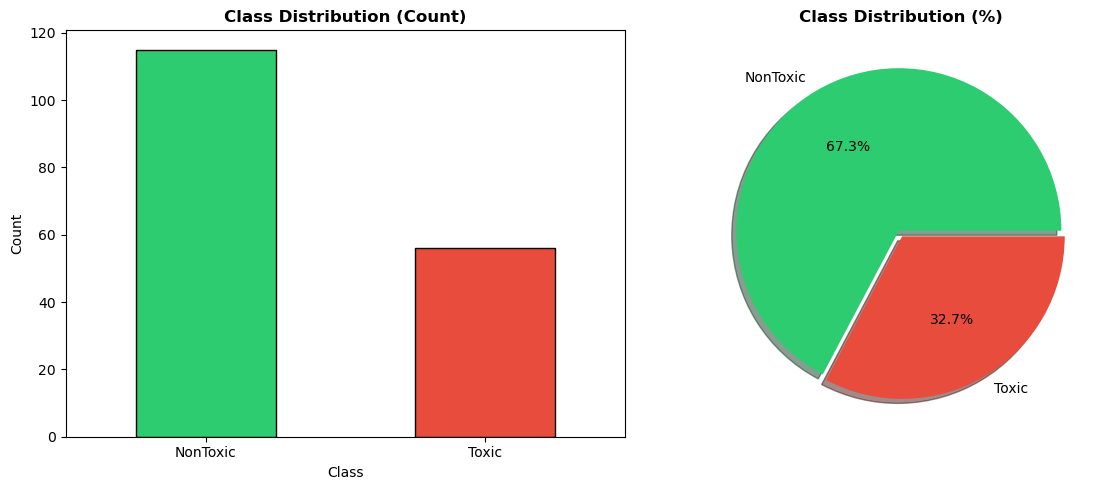


Target distribution visualization saved!


In [5]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
colors = ['#2ecc71', '#e74c3c']  # Green for NonToxic, Red for Toxic
target_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%', 
            colors=colors, explode=(0.02, 0.02), shadow=True)
axes[1].set_title('Class Distribution (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTarget distribution visualization saved!")

In [6]:
# Analyze feature characteristics
print(f"\nFeature Analysis:")
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"  Numeric features: {len(numeric_features)}")

# Check for constant/near-constant features
constant_features = []
low_variance_features = []
for col in numeric_features:
    unique_count = X[col].nunique()
    if unique_count == 1:
        constant_features.append(col)
    elif unique_count <= 2:
        low_variance_features.append(col)

print(f"  Constant features: {len(constant_features)}")
print(f"  Low variance features (<=2 unique): {len(low_variance_features)}")

# Check for infinite values
inf_counts = np.isinf(X[numeric_features]).sum().sum()
print(f"  Infinite values: {inf_counts}")

# Basic statistics for a sample of features
print(f"\nSample Feature Statistics (first 5 features):")
print(X[numeric_features[:5]].describe())


Feature Analysis:
  Numeric features: 1203
  Constant features: 0
  Low variance features (<=2 unique): 46
  Infinite values: 0

Sample Feature Statistics (first 5 features):
           MATS3v    nHBint10      MATS3s      MATS3p  nHBDon_Lipinski
count  171.000000  171.000000  171.000000  171.000000       171.000000
mean    -0.031244    0.315789   -0.001001   -0.061501         0.994152
std      0.063559    0.762918    0.063928    0.072891         1.108773
min     -0.311500    0.000000   -0.184600   -0.348500         0.000000
25%     -0.066700    0.000000   -0.036000   -0.099550         0.000000
50%     -0.032500    0.000000   -0.002000   -0.059400         1.000000
75%      0.004850    0.000000    0.029000   -0.017100         2.000000
max      0.141100    4.000000    0.218100    0.129000         6.000000


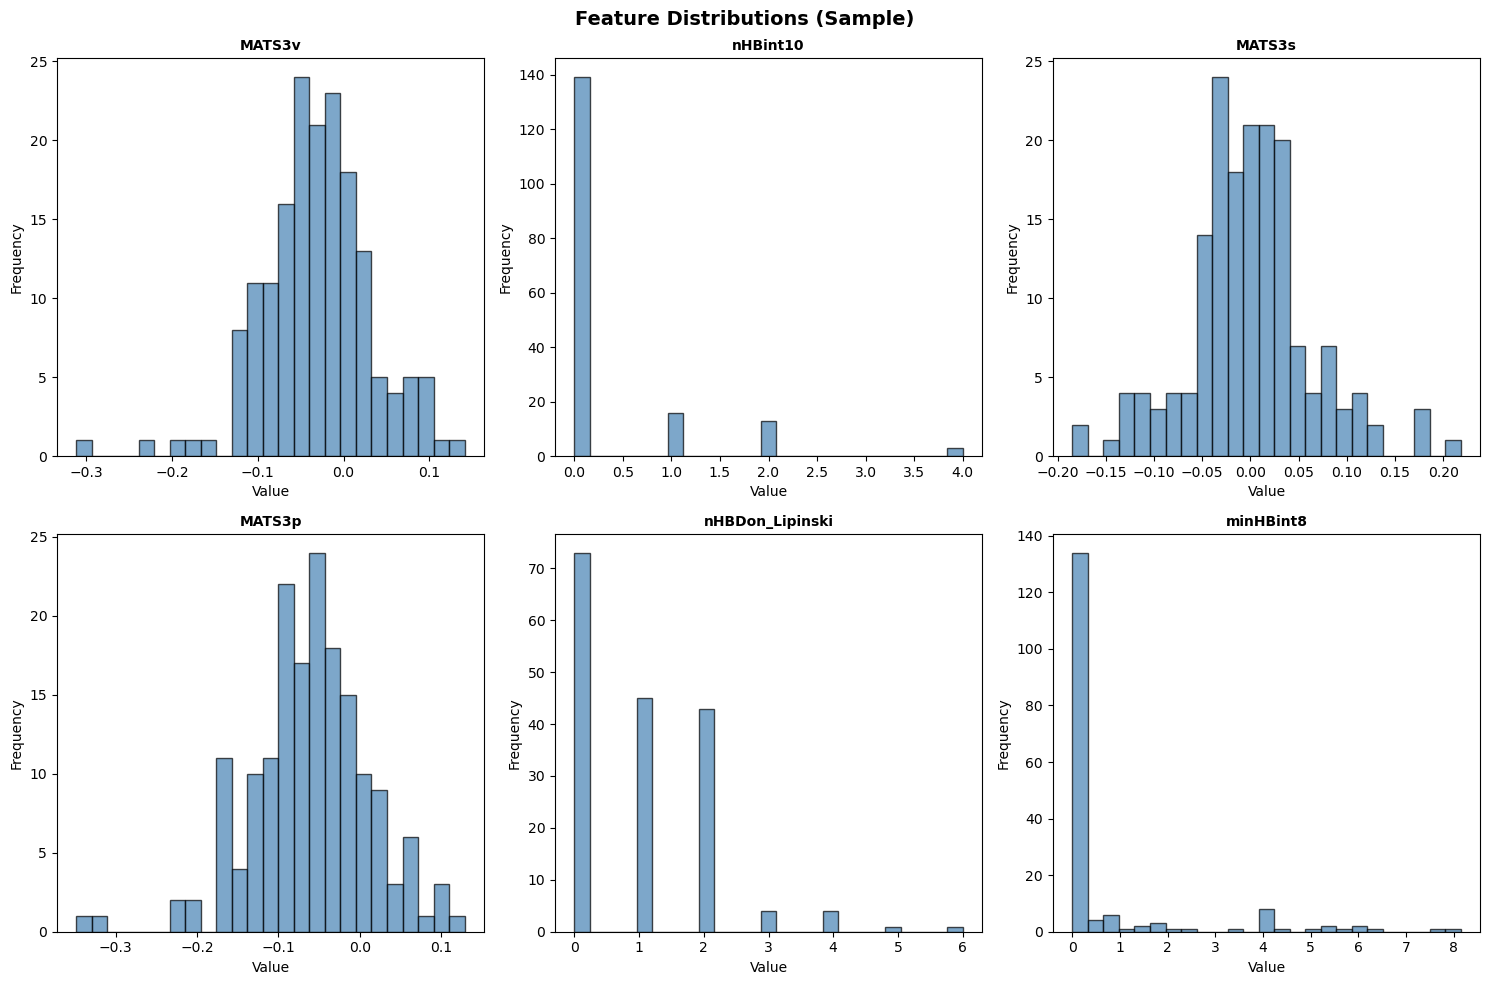

In [7]:
# Distribution analysis for sample features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_features[:6]):
    axes[idx].hist(X[col], bins=25, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

plt.suptitle('Feature Distributions (Sample)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

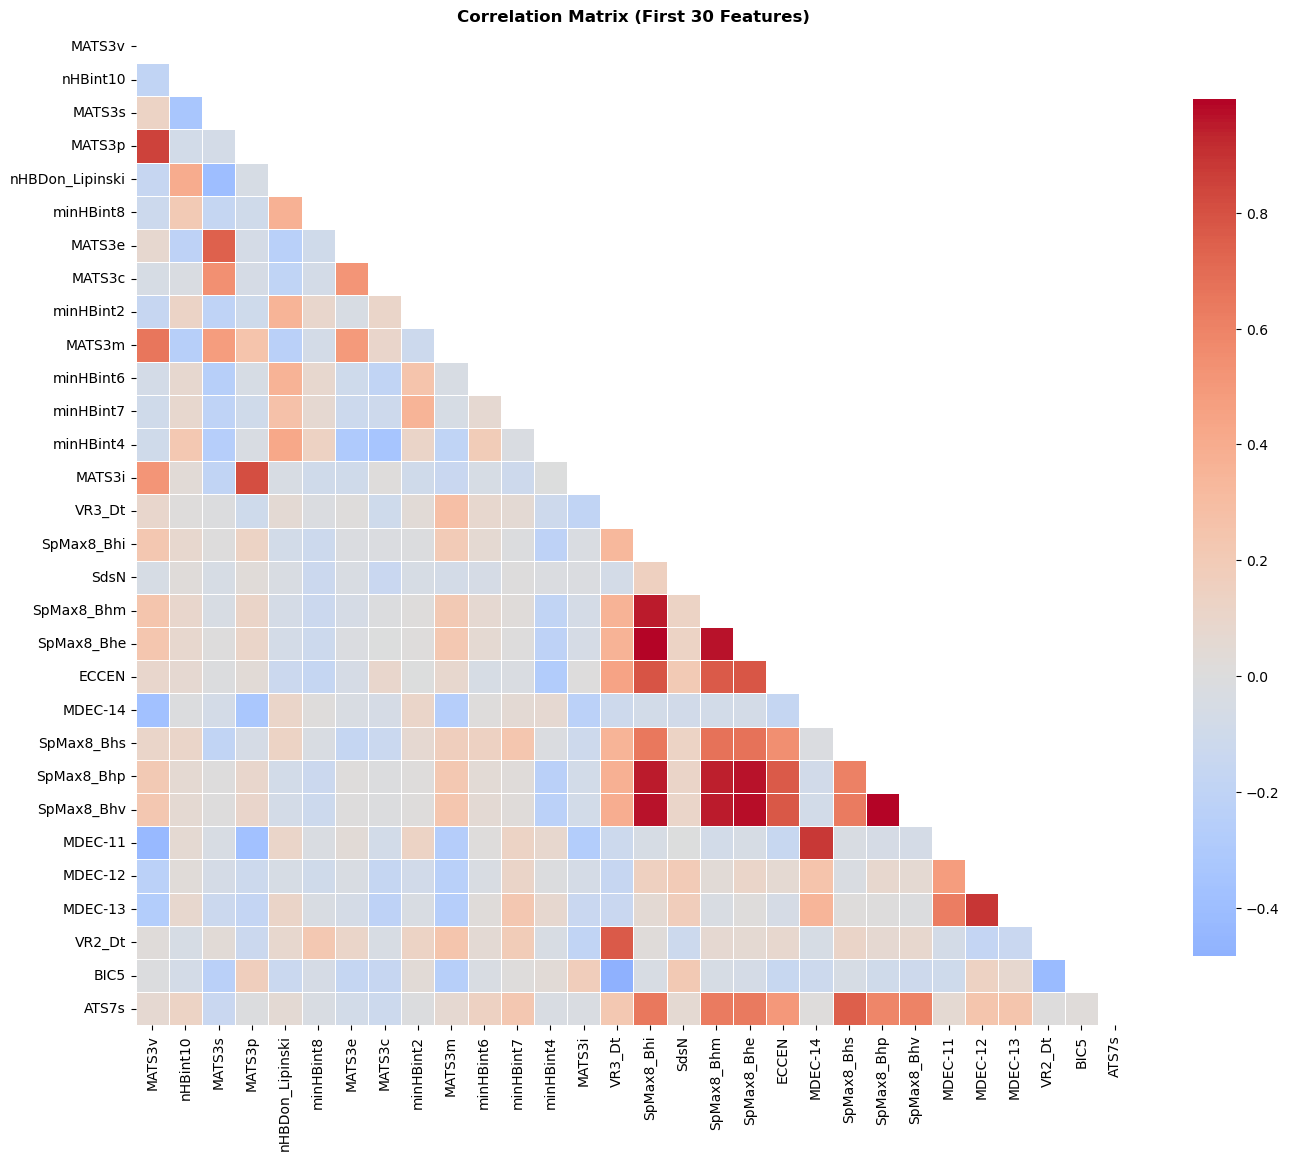


Highly correlated pairs (|r| > 0.9): 10
  SpMax8_Bhi - SpMax8_Bhm: 0.952
  SpMax8_Bhi - SpMax8_Bhe: 0.993
  SpMax8_Bhi - SpMax8_Bhp: 0.954
  SpMax8_Bhi - SpMax8_Bhv: 0.963
  SpMax8_Bhm - SpMax8_Bhe: 0.968


In [8]:
# Correlation analysis (sample of features to avoid memory issues)
sample_size = min(30, len(numeric_features))
corr_matrix = X[numeric_features[:sample_size]].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title(f'Correlation Matrix (First {sample_size} Features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], 
                                   corr_matrix.iloc[i, j]))

print(f"\nHighly correlated pairs (|r| > 0.9): {len(high_corr_pairs)}")
for pair in high_corr_pairs[:5]:
    print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")

In [9]:
# ============================================
# 2. PREPROCESSING
# ============================================

print("\n" + "="*80)
print("STEP 2: PREPROCESSING")
print("="*80)

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"\nClass encoding: {class_mapping}")

# Remove constant features
print(f"\nRemoving {len(constant_features)} constant features...")
X_clean = X.drop(columns=constant_features) if constant_features else X.copy()
print(f"Shape after removing constants: {X_clean.shape}")

# Handle infinite values
print(f"\nHandling infinite values...")
X_clean = X_clean.replace([np.inf, -np.inf], np.nan)

# Impute missing values with median
X_imputed = X_clean.fillna(X_clean.median())
print(f"Missing values after imputation: {X_imputed.isnull().sum().sum()}")

# Check for any remaining issues
print(f"\nFinal check:")
print(f"  Shape: {X_imputed.shape}")
print(f"  Infinite values: {np.isinf(X_imputed.select_dtypes(include=[np.number])).sum().sum()}")
print(f"  Missing values: {X_imputed.isnull().sum().sum()}")


STEP 2: PREPROCESSING

Class encoding: {'NonToxic': np.int64(0), 'Toxic': np.int64(1)}

Removing 0 constant features...
Shape after removing constants: (171, 1203)

Handling infinite values...
Missing values after imputation: 0

Final check:
  Shape: (171, 1203)
  Infinite values: 0
  Missing values: 0


In [10]:
# Feature scaling - using RobustScaler for outlier resistance
print(f"\nApplying RobustScaler (outlier-resistant)...")
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_imputed)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_imputed.columns)

print(f"Scaling complete. Feature statistics after scaling:")
print(X_scaled_df.describe().loc[['mean', 'std', 'min', 'max']])


Applying RobustScaler (outlier-resistant)...
Scaling complete. Feature statistics after scaling:
        MATS3v  nHBint10    MATS3s    MATS3p  nHBDon_Lipinski  minHBint8  \
mean  0.017556  0.315789  0.015376 -0.025477        -0.002924   0.677770   
std   0.888313  0.762918  0.983505  0.884067         0.554386   1.647322   
min  -3.899371  0.000000 -2.809231 -3.506367        -0.500000   0.000000   
max   2.426275  4.000000  3.386154  2.285021         2.500000   8.141400   

        MATS3e    MATS3c  minHBint2    MATS3m  ...    WTPT-3    WTPT-4  \
mean  0.170267 -0.082273   0.320422  0.044313  ...  0.010219  0.051785   
std   1.136484  0.827071   0.509931  0.680223  ...  0.835528  0.803883   
min  -2.524566 -3.252739  -0.144708 -1.809917  ... -3.003353 -1.421969   
max   4.143064  1.923687   1.580578  1.561065  ...  2.364782  2.347638   

        WTPT-5  ETA_EtaP_L  ETA_EtaP_F  ETA_EtaP_B   nT5Ring     SHdNH  \
mean  0.014057    0.078637   -0.021111    0.096975  0.467836  0.004820   
st


STEP 3: FEATURE SELECTION

Train set: (136, 1203)
Test set: (35, 1203)

Method 1: F-Score (ANOVA F-test)
Top 15 features by F-score:
  minssNH: 5.799
  AATSC5m: 5.632
  GATS7c: 5.476
  ATSC5m: 5.437
  minHssNH: 5.310
  maxssNH: 5.273
  MATS8c: 5.016
  EE_Dt: 4.930
  nwHBa: 4.929
  MATS5m: 4.895
  C2SP2: 4.887
  AATSC7c: 4.641
  GATS7v: 4.437
  maxHssNH: 4.410
  nHother: 4.393


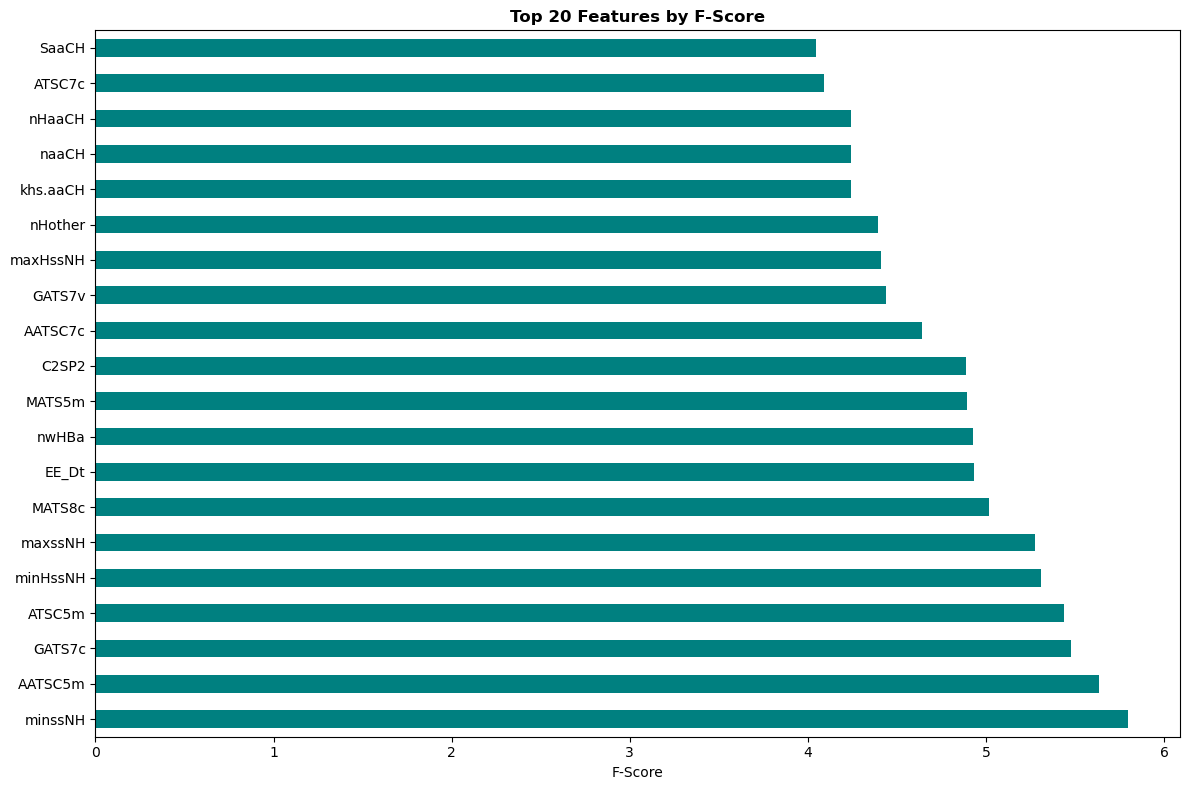

In [11]:
# ============================================
# 3. FEATURE SELECTION
# ============================================

print("\n" + "="*80)
print("STEP 3: FEATURE SELECTION")
print("="*80)

# Split data for feature selection evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Method 1: Univariate Feature Selection (F-score)
print(f"\n{'='*60}")
print("Method 1: F-Score (ANOVA F-test)")
print(f"{'='*60}")

selector_f = SelectKBest(score_func=f_classif, k=50)
X_train_f = selector_f.fit_transform(X_train, y_train)
f_scores = selector_f.scores_
f_selected_mask = selector_f.get_support()

f_selected_features = X_imputed.columns[f_selected_mask].tolist()
f_scores_selected = f_scores[f_selected_mask]

print(f"Top 15 features by F-score:")
top_f_idx = np.argsort(f_scores_selected)[::-1][:15]
for idx in top_f_idx:
    print(f"  {f_selected_features[idx]}: {f_scores_selected[idx]:.3f}")

# Visualize F-scores
plt.figure(figsize=(12, 8))
f_scores_series = pd.Series(f_scores, index=X_imputed.columns).sort_values(ascending=False)
f_scores_series.head(20).plot(kind='barh', color='teal')
plt.title('Top 20 Features by F-Score', fontsize=12, fontweight='bold')
plt.xlabel('F-Score')
plt.tight_layout()
plt.savefig('f_score_selection.png', dpi=150, bbox_inches='tight')
plt.show()


Method 2: Mutual Information
Top 15 features by Mutual Information:
  MWC3: 0.136
  GGI3: 0.131
  MATS4i: 0.123
  CIC2: 0.116
  AATSC0p: 0.116
  nHBint10: 0.115
  CIC1: 0.113
  SpMin4_Bhe: 0.111
  MPC6: 0.110
  DELS: 0.110
  JGI9: 0.106
  ATSC8i: 0.105
  nAtomLC: 0.101
  SpMax8_Bhi: 0.099
  SaaN: 0.099


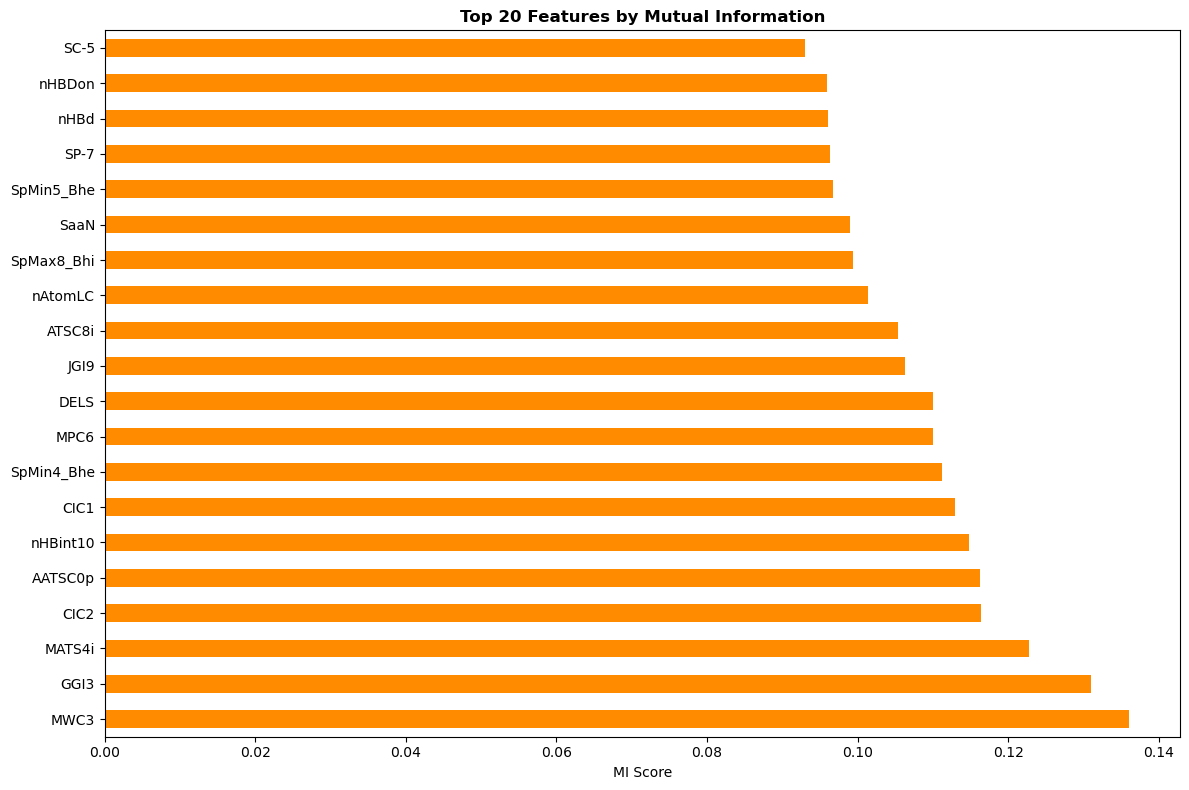

In [12]:
# Method 2: Mutual Information
print(f"\n{'='*60}")
print("Method 2: Mutual Information")
print(f"{'='*60}")

selector_mi = SelectKBest(score_func=mutual_info_classif, k=50)
X_train_mi = selector_mi.fit_transform(X_train, y_train)
mi_scores = selector_mi.scores_
mi_selected_mask = selector_mi.get_support()

mi_selected_features = X_imputed.columns[mi_selected_mask].tolist()
mi_scores_selected = mi_scores[mi_selected_mask]

print(f"Top 15 features by Mutual Information:")
top_mi_idx = np.argsort(mi_scores_selected)[::-1][:15]
for idx in top_mi_idx:
    print(f"  {mi_selected_features[idx]}: {mi_scores_selected[idx]:.3f}")

plt.figure(figsize=(12, 8))
mi_scores_series = pd.Series(mi_scores, index=X_imputed.columns).sort_values(ascending=False)
mi_scores_series.head(20).plot(kind='barh', color='darkorange')
plt.title('Top 20 Features by Mutual Information', fontsize=12, fontweight='bold')
plt.xlabel('MI Score')
plt.tight_layout()
plt.savefig('mutual_info_selection.png', dpi=150, bbox_inches='tight')
plt.show()


Method 3: Random Forest Feature Importance
Top 15 features by RF Importance:
  GATS7c: 0.0065
  ATSC7c: 0.0061
  VR2_Dzv: 0.0048
  LipoaffinityIndex: 0.0044
  AATSC3v: 0.0042
  AATSC5m: 0.0040
  SpMax8_Bhi: 0.0039
  SpMAD_Dt: 0.0038
  ATSC5m: 0.0038
  EE_Dt: 0.0038
  MATS8i: 0.0037
  MATS6c: 0.0036
  ATSC7p: 0.0036
  GATS8e: 0.0035
  MATS5m: 0.0035


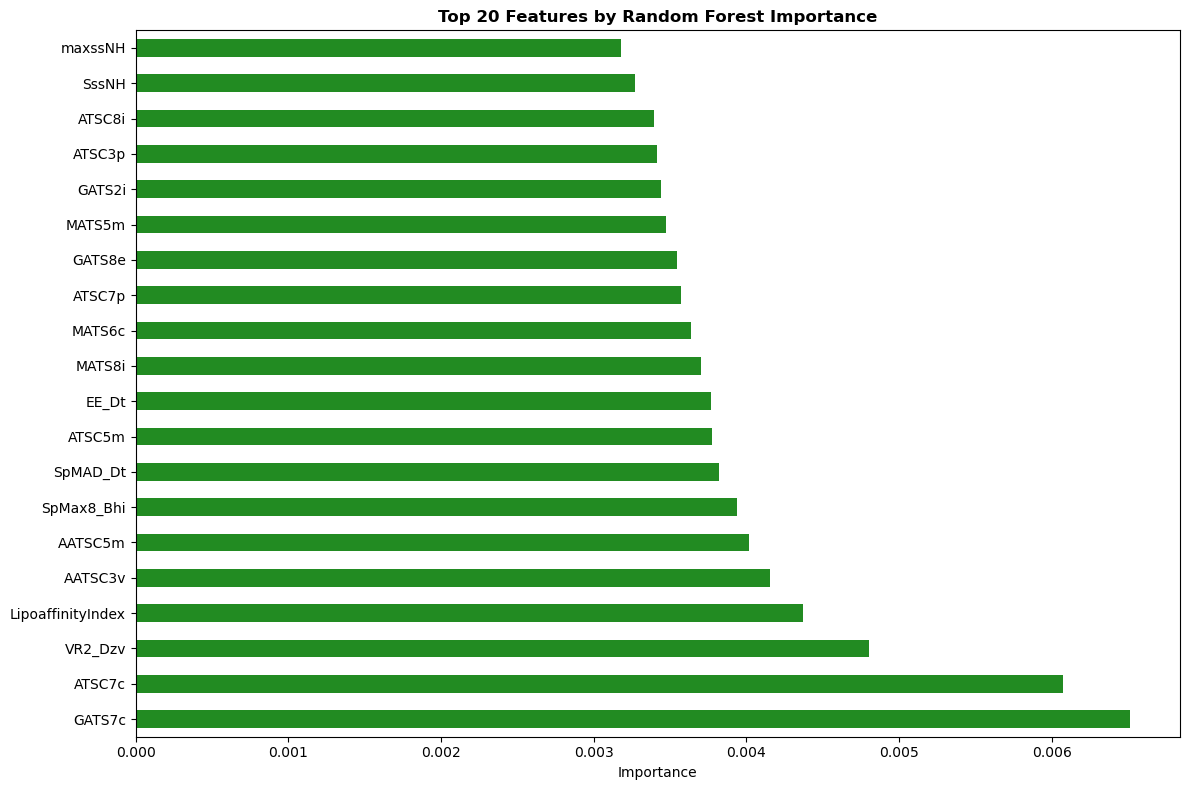

In [13]:
# Method 3: Random Forest Feature Importance
print(f"\n{'='*60}")
print("Method 3: Random Forest Feature Importance")
print(f"{'='*60}")

rf_selector = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf_selector.fit(X_train, y_train)

rf_importances = pd.Series(rf_selector.feature_importances_, index=X_imputed.columns)
rf_importances_sorted = rf_importances.sort_values(ascending=False)

print(f"Top 15 features by RF Importance:")
for feat, imp in rf_importances_sorted.head(15).items():
    print(f"  {feat}: {imp:.4f}")

plt.figure(figsize=(12, 8))
rf_importances_sorted.head(20).plot(kind='barh', color='forestgreen')
plt.title('Top 20 Features by Random Forest Importance', fontsize=12, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()


Method 4: RFECV with Random Forest
Optimal number of features (RFECV): 1
Selected 1 features


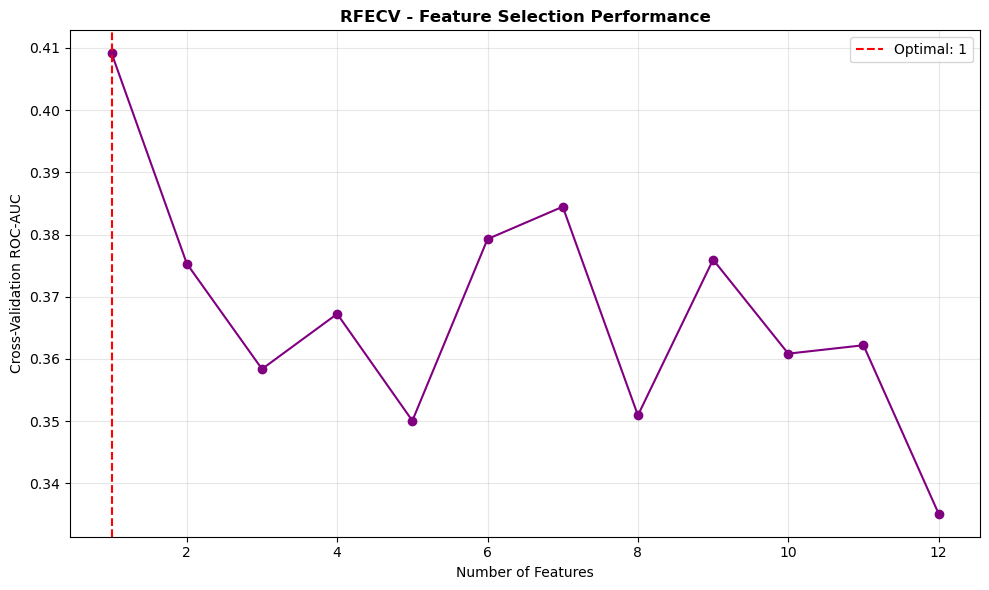

In [14]:
# Method 4: Recursive Feature Elimination with Cross-Validation (RFECV)
print(f"\n{'='*60}")
print("Method 4: RFECV with Random Forest")
print(f"{'='*60}")

# Use smaller feature set for RFECV due to computational cost
rfe_estimator = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
rfecv = RFECV(estimator=rfe_estimator, step=0.1, cv=StratifiedKFold(3), scoring='roc_auc', n_jobs=-1)
rfecv.fit(X_train, y_train)

rfe_selected_features = X_imputed.columns[rfecv.support_].tolist()
print(f"Optimal number of features (RFECV): {rfecv.n_features_}")
print(f"Selected {len(rfe_selected_features)} features")

# Plot RFECV results
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), 
         rfecv.cv_results_['mean_test_score'], 'o-', color='purple')
plt.axvline(x=rfecv.n_features_, color='r', linestyle='--', 
            label=f'Optimal: {rfecv.n_features_}')
plt.xlabel('Number of Features')
plt.ylabel('Cross-Validation ROC-AUC')
plt.title('RFECV - Feature Selection Performance', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rfecv_performance.png', dpi=150, bbox_inches='tight')
plt.show()


CONSENSUS FEATURE SELECTION

Features with at least 2 votes: 22

Voting distribution:
  0 votes: 1076 features
  1 votes: 105 features
  2 votes: 20 features
  3 votes: 2 features


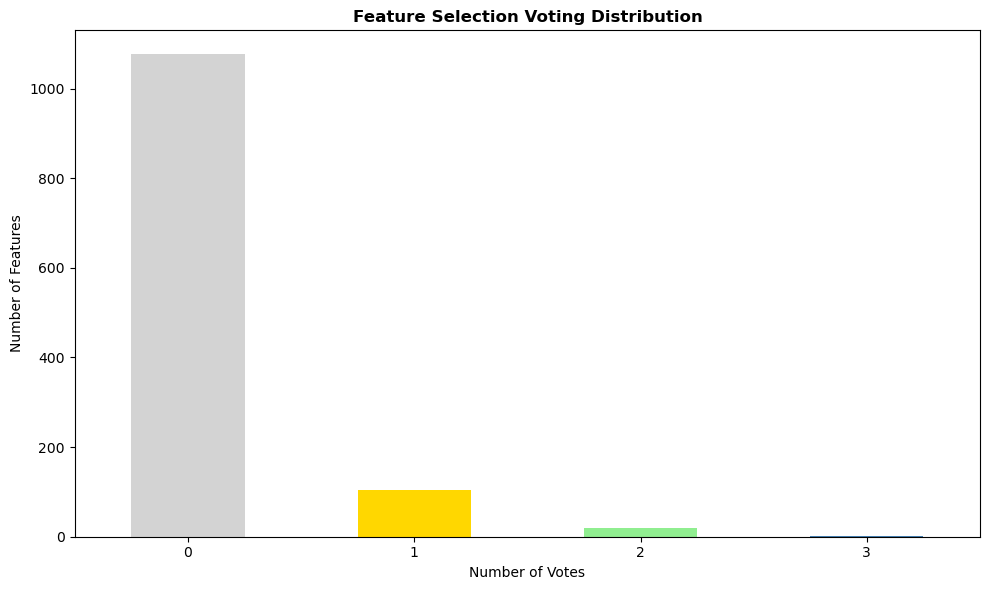


Top consensus features (4 votes):


In [15]:
# Consensus Feature Selection
print(f"\n{'='*60}")
print("CONSENSUS FEATURE SELECTION")
print(f"{'='*60}")

# Create voting system
feature_votes = pd.Series(0, index=X_imputed.columns)

# Add votes from each method
feature_votes[f_selected_features] += 1
feature_votes[mi_selected_features] += 1
feature_votes[rf_importances_sorted.head(50).index] += 1
feature_votes[rfe_selected_features] += 1

# Select features with at least 2 votes
consensus_features = feature_votes[feature_votes >= 2].index.tolist()
print(f"\nFeatures with at least 2 votes: {len(consensus_features)}")

# Show voting distribution
vote_dist = feature_votes.value_counts().sort_index()
print(f"\nVoting distribution:")
for votes, count in vote_dist.items():
    print(f"  {int(votes)} votes: {count} features")

# Visualize consensus
plt.figure(figsize=(10, 6))
colors = ['lightgray', 'gold', 'lightgreen', 'steelblue', 'darkblue']
vote_dist.plot(kind='bar', color=colors[:len(vote_dist)])
plt.title('Feature Selection Voting Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Number of Votes')
plt.ylabel('Number of Features')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('consensus_voting.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop consensus features (4 votes):")
top_consensus = feature_votes[feature_votes == 4].index.tolist()
for feat in top_consensus[:10]:
    print(f"  - {feat}")

In [16]:
# Prepare final feature sets for modeling
print(f"\n{'='*60}")
print("FINAL FEATURE SETS PREPARATION")
print(f"{'='*60}")

# Option 1: Consensus features (≥2 votes)
X_train_consensus = X_train[:, [X_imputed.columns.get_loc(f) for f in consensus_features]]
X_test_consensus = X_test[:, [X_imputed.columns.get_loc(f) for f in consensus_features]]

# Option 2: Top 30 RF features
top30_rf = rf_importances_sorted.head(30).index.tolist()
X_train_top30 = X_train[:, [X_imputed.columns.get_loc(f) for f in top30_rf]]
X_test_top30 = X_test[:, [X_imputed.columns.get_loc(f) for f in top30_rf]]

# Option 3: RFECV selected features
X_train_rfecv = X_train[:, rfecv.support_]
X_test_rfecv = X_test[:, rfecv.support_]

print(f"Feature set shapes:")
print(f"  Consensus (≥2 votes): {X_train_consensus.shape[1]} features")
print(f"  Top 30 RF: {X_train_top30.shape[1]} features")
print(f"  RFECV optimal: {X_train_rfecv.shape[1]} features")

# Use consensus features for final modeling (best balance)
X_train_final = X_train_consensus
X_test_final = X_test_consensus
final_feature_names = consensus_features

print(f"\nSelected feature set: Consensus ({len(consensus_features)} features)")


FINAL FEATURE SETS PREPARATION
Feature set shapes:
  Consensus (≥2 votes): 22 features
  Top 30 RF: 30 features
  RFECV optimal: 1 features

Selected feature set: Consensus (22 features)


In [17]:
# ============================================
# 4. MODEL BUILDING WITH CROSS-VALIDATION
# ============================================

print("\n" + "="*80)
print("STEP 4: MODEL BUILDING WITH CROSS-VALIDATION")
print("="*80)

# Define cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Model 1: Random Forest with Hyperparameter Tuning
print(f"\n{'='*60}")
print("Model 1: Random Forest (with Grid Search CV)")
print(f"{'='*60}")

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_params,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_final, y_train)
best_rf = rf_grid.best_estimator_

print(f"\nBest RF Parameters: {rf_grid.best_params_}")
print(f"Best CV ROC-AUC: {rf_grid.best_score_:.4f}")

# Cross-validation results for best RF
rf_cv_scores = cross_validate(
    best_rf, X_train_final, y_train, 
    cv=cv_strategy, 
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True
)

print(f"\nRandom Forest CV Results (5-fold):")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    mean_score = rf_cv_scores[f'test_{metric}'].mean()
    std_score = rf_cv_scores[f'test_{metric}'].std()
    print(f"  {metric.upper()}: {mean_score:.4f} (+/- {std_score*2:.4f})")


STEP 4: MODEL BUILDING WITH CROSS-VALIDATION

Model 1: Random Forest (with Grid Search CV)
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best RF Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV ROC-AUC: 0.6901

Random Forest CV Results (5-fold):
  ACCURACY: 0.6545 (+/- 0.0562)
  PRECISION: 0.3857 (+/- 0.4430)
  RECALL: 0.2222 (+/- 0.3143)
  F1: 0.2691 (+/- 0.3333)
  ROC_AUC: 0.6901 (+/- 0.1167)


In [18]:
# Model 2: Gradient Boosting
print(f"\n{'='*60}")
print("Model 2: Gradient Boosting Classifier")
print(f"{'='*60}")

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_params,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train_final, y_train)
best_gb = gb_grid.best_estimator_

print(f"\nBest GB Parameters: {gb_grid.best_params_}")
print(f"Best CV ROC-AUC: {gb_grid.best_score_:.4f}")

gb_cv_scores = cross_validate(
    best_gb, X_train_final, y_train,
    cv=cv_strategy,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

print(f"\nGradient Boosting CV Results (5-fold):")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    mean_score = gb_cv_scores[f'test_{metric}'].mean()
    std_score = gb_cv_scores[f'test_{metric}'].std()
    print(f"  {metric.upper()}: {mean_score:.4f} (+/- {std_score*2:.4f})")


Model 2: Gradient Boosting Classifier
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best GB Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}
Best CV ROC-AUC: 0.6363

Gradient Boosting CV Results (5-fold):
  ACCURACY: 0.6548 (+/- 0.1876)
  PRECISION: 0.4572 (+/- 0.4675)
  RECALL: 0.3333 (+/- 0.3718)
  F1: 0.3783 (+/- 0.3961)
  ROC_AUC: 0.6363 (+/- 0.3130)


In [19]:
# Model 3: Ensemble - Voting Classifier
print(f"\n{'='*60}")
print("Model 3: Voting Ensemble (RF + GB + SVM)")
print(f"{'='*60}")

# SVM for diversity
svm_clf = SVC(probability=True, kernel='rbf', C=1.0, random_state=RANDOM_STATE)

# Voting Classifier (Soft Voting)
voting_clf = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('gb', best_gb),
        ('svm', svm_clf)
    ],
    voting='soft'
)

voting_cv_scores = cross_validate(
    voting_clf, X_train_final, y_train,
    cv=cv_strategy,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

print(f"\nVoting Ensemble CV Results (5-fold):")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    mean_score = voting_cv_scores[f'test_{metric}'].mean()
    std_score = voting_cv_scores[f'test_{metric}'].std()
    print(f"  {metric.upper()}: {mean_score:.4f} (+/- {std_score*2:.4f})")


Model 3: Voting Ensemble (RF + GB + SVM)

Voting Ensemble CV Results (5-fold):
  ACCURACY: 0.6693 (+/- 0.1299)
  PRECISION: 0.5110 (+/- 0.5328)
  RECALL: 0.2444 (+/- 0.2592)
  F1: 0.3212 (+/- 0.3061)
  ROC_AUC: 0.6674 (+/- 0.2331)


In [20]:
# Model 4: Stacking Ensemble
print(f"\n{'='*60}")
print("Model 4: Stacking Ensemble")
print(f"{'='*60}")

# Define base learners
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=8, random_state=RANDOM_STATE)),
    ('gb', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE)),
    ('svm', SVC(probability=True, kernel='rbf', C=1.0, random_state=RANDOM_STATE))
]

# Stacking classifier with Logistic Regression as meta-learner
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=5,
    stack_method='predict_proba'
)

stacking_cv_scores = cross_validate(
    stacking_clf, X_train_final, y_train,
    cv=cv_strategy,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

print(f"\nStacking Ensemble CV Results (5-fold):")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    mean_score = stacking_cv_scores[f'test_{metric}'].mean()
    std_score = stacking_cv_scores[f'test_{metric}'].std()
    print(f"  {metric.upper()}: {mean_score:.4f} (+/- {std_score*2:.4f})")


Model 4: Stacking Ensemble

Stacking Ensemble CV Results (5-fold):
  ACCURACY: 0.6839 (+/- 0.0576)
  PRECISION: 0.1500 (+/- 0.6000)
  RECALL: 0.0667 (+/- 0.2667)
  F1: 0.0923 (+/- 0.3692)
  ROC_AUC: 0.6468 (+/- 0.1877)


In [21]:
# ============================================
# 5. FINAL MODEL EVALUATION ON TEST SET
# ============================================

print("\n" + "="*80)
print("STEP 5: FINAL EVALUATION ON TEST SET")
print("="*80)

# Train all models on full training data
models = {
    'Random Forest': best_rf,
    'Gradient Boosting': best_gb,
    'Voting Ensemble': voting_clf,
    'Stacking Ensemble': stacking_clf
}

results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {name}")
    print(f"{'='*60}")
    
    # Train
    model.fit(X_train_final, y_train)
    
    # Predict
    y_pred = model.predict(X_test_final)
    y_prob = model.predict_proba(X_test_final)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    
    print(f"\nTest Set Performance:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


STEP 5: FINAL EVALUATION ON TEST SET

Evaluating: Random Forest

Test Set Performance:
  Accuracy:  0.6286
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  ROC-AUC:   0.4962

Classification Report:
              precision    recall  f1-score   support

    NonToxic       0.67      0.92      0.77        24
       Toxic       0.00      0.00      0.00        11

    accuracy                           0.63        35
   macro avg       0.33      0.46      0.39        35
weighted avg       0.46      0.63      0.53        35


Evaluating: Gradient Boosting

Test Set Performance:
  Accuracy:  0.6286
  Precision: 0.2500
  Recall:    0.0909
  F1-Score:  0.1333
  ROC-AUC:   0.5606

Classification Report:
              precision    recall  f1-score   support

    NonToxic       0.68      0.88      0.76        24
       Toxic       0.25      0.09      0.13        11

    accuracy                           0.63        35
   macro avg       0.46      0.48      0.45        35
weighted av


MODEL COMPARISON SUMMARY

Test Set Performance Comparison:
                   Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest        0.6286     0.0000  0.0000    0.0000   0.4962
Gradient Boosting    0.6286     0.2500  0.0909    0.1333   0.5606
Voting Ensemble      0.6571     0.3333  0.0909    0.1429   0.4735
Stacking Ensemble    0.6571     0.0000  0.0000    0.0000   0.5303


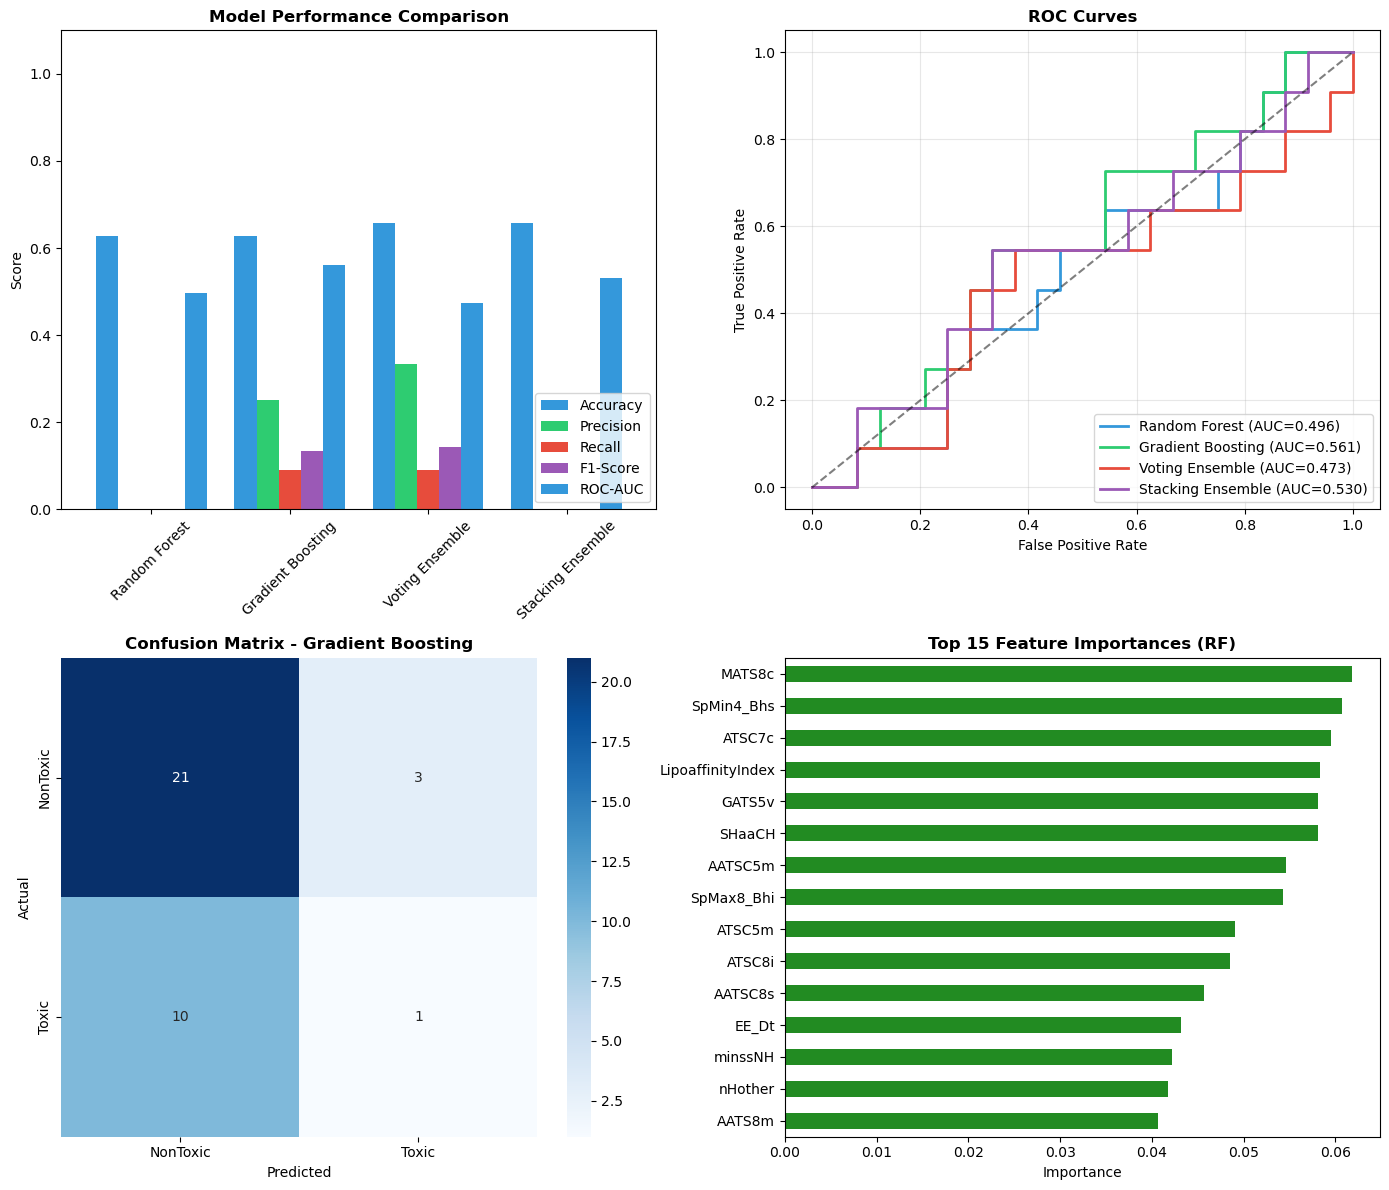


Best performing model: Gradient Boosting
Best ROC-AUC: 0.5606


In [22]:
# Compare all models
print(f"\n{'='*60}")
print("MODEL COMPARISON SUMMARY")
print(f"{'='*60}")

comparison_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k not in ['y_pred', 'y_prob']}
    for name, metrics in results.items()
}).T

print(f"\nTest Set Performance Comparison:")
print(comparison_df.round(4))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

# Bar plot comparison
ax1 = axes[0, 0]
comparison_df.plot(kind='bar', ax=ax1, color=colors, width=0.8)
ax1.set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score')
ax1.legend(loc='lower right')
ax1.set_ylim(0, 1.1)
ax1.tick_params(axis='x', rotation=45)

# ROC Curves
ax2 = axes[0, 1]
for idx, (name, metrics) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, metrics['y_prob'])
    ax2.plot(fpr, tpr, label=f"{name} (AUC={metrics['ROC-AUC']:.3f})", 
             color=colors[idx], linewidth=2)
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# Confusion Matrix for best model (highest ROC-AUC)
best_model_name = comparison_df['ROC-AUC'].idxmax()
best_pred = results[best_model_name]['y_pred']

ax3 = axes[1, 0]
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax3.set_title(f'Confusion Matrix - {best_model_name}', fontsize=12, fontweight='bold')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

# Feature Importance (if available)
ax4 = axes[1, 1]
if hasattr(best_rf, 'feature_importances_'):
    importances = pd.Series(best_rf.feature_importances_, index=final_feature_names)
    importances.sort_values(ascending=True).tail(15).plot(kind='barh', ax=ax4, color='forestgreen')
    ax4.set_title('Top 15 Feature Importances (RF)', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest performing model: {best_model_name}")
print(f"Best ROC-AUC: {comparison_df.loc[best_model_name, 'ROC-AUC']:.4f}")

In [23]:
# ============================================
# 6. FINAL SUMMARY AND RECOMMENDATIONS
# ============================================

print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print(f"\nDataset Summary:")
print(f"  - Total samples: {len(df)}")
print(f"  - Original features: {X.shape[1]}")
print(f"  - Selected features: {len(consensus_features)} (consensus approach)")
print(f"  - Classes: {dict(zip(range(len(le.classes_)), le.classes_))}")

print(f"\nPreprocessing Applied:")
print(f"  1. Removed {len(constant_features)} constant features")
print(f"  2. Handled infinite values (replaced with median)")
print(f"  3. Applied RobustScaler (outlier-resistant)")

print(f"\nFeature Selection Methods Used:")
print(f"  - F-Score (ANOVA): Selected top 50")
print(f"  - Mutual Information: Selected top 50")
print(f"  - Random Forest Importance: Selected top 50")
print(f"  - RFECV: Selected optimal {rfecv.n_features_} features")
print(f"  - Final consensus: {len(consensus_features)} features (≥2 votes)")

print(f"\nModels Evaluated (5-Fold Cross-Validation + Test Set):")
for name in models.keys():
    cv_auc = 0
    if name == 'Random Forest':
        cv_auc = rf_cv_scores['test_roc_auc'].mean()
    elif name == 'Gradient Boosting':
        cv_auc = gb_cv_scores['test_roc_auc'].mean()
    elif name == 'Voting Ensemble':
        cv_auc = voting_cv_scores['test_roc_auc'].mean()
    elif name == 'Stacking Ensemble':
        cv_auc = stacking_cv_scores['test_roc_auc'].mean()
    
    test_auc = results[name]['ROC-AUC']
    print(f"  - {name}:")
    print(f"      CV ROC-AUC:  {cv_auc:.4f}")
    print(f"      Test ROC-AUC: {test_auc:.4f}")

print(f"\nRecommended Model: {best_model_name}")
print(f"Recommended Features: {len(consensus_features)} consensus features")

# Save final predictions
final_predictions = pd.DataFrame({
    'Actual': le.inverse_transform(y_test),
    'Predicted': le.inverse_transform(results[best_model_name]['y_pred']),
    'Probability_Toxic': results[best_model_name]['y_prob']
})
print(f"\nSample Predictions:")
print(final_predictions.head(10))


FINAL SUMMARY

Dataset Summary:
  - Total samples: 171
  - Original features: 1203
  - Selected features: 22 (consensus approach)
  - Classes: {0: 'NonToxic', 1: 'Toxic'}

Preprocessing Applied:
  1. Removed 0 constant features
  2. Handled infinite values (replaced with median)
  3. Applied RobustScaler (outlier-resistant)

Feature Selection Methods Used:
  - F-Score (ANOVA): Selected top 50
  - Mutual Information: Selected top 50
  - Random Forest Importance: Selected top 50
  - RFECV: Selected optimal 1 features
  - Final consensus: 22 features (≥2 votes)

Models Evaluated (5-Fold Cross-Validation + Test Set):
  - Random Forest:
      CV ROC-AUC:  0.6901
      Test ROC-AUC: 0.4962
  - Gradient Boosting:
      CV ROC-AUC:  0.6363
      Test ROC-AUC: 0.5606
  - Voting Ensemble:
      CV ROC-AUC:  0.6674
      Test ROC-AUC: 0.4735
  - Stacking Ensemble:
      CV ROC-AUC:  0.6468
      Test ROC-AUC: 0.5303

Recommended Model: Gradient Boosting
Recommended Features: 22 consensus feature


FEATURE IMPORTANCE ANALYSIS

Top 20 Most Important Features for Toxicity Prediction:
   1. MATS8c: 0.0618
   2. SpMin4_Bhs: 0.0607
   3. ATSC7c: 0.0595
   4. LipoaffinityIndex: 0.0583
   5. GATS5v: 0.0581
   6. SHaaCH: 0.0581
   7. AATSC5m: 0.0547
   8. SpMax8_Bhi: 0.0543
   9. ATSC5m: 0.0491
  10. ATSC8i: 0.0485
  11. AATSC8s: 0.0457
  12. EE_Dt: 0.0432
  13. minssNH: 0.0422
  14. nHother: 0.0418
  15. AATS8m: 0.0407
  16. GATS7c: 0.0402
  17. MATS4i: 0.0388
  18. MATS8s: 0.0360
  19. SpMin1_Bhv: 0.0300
  20. SpMin4_Bhe: 0.0294


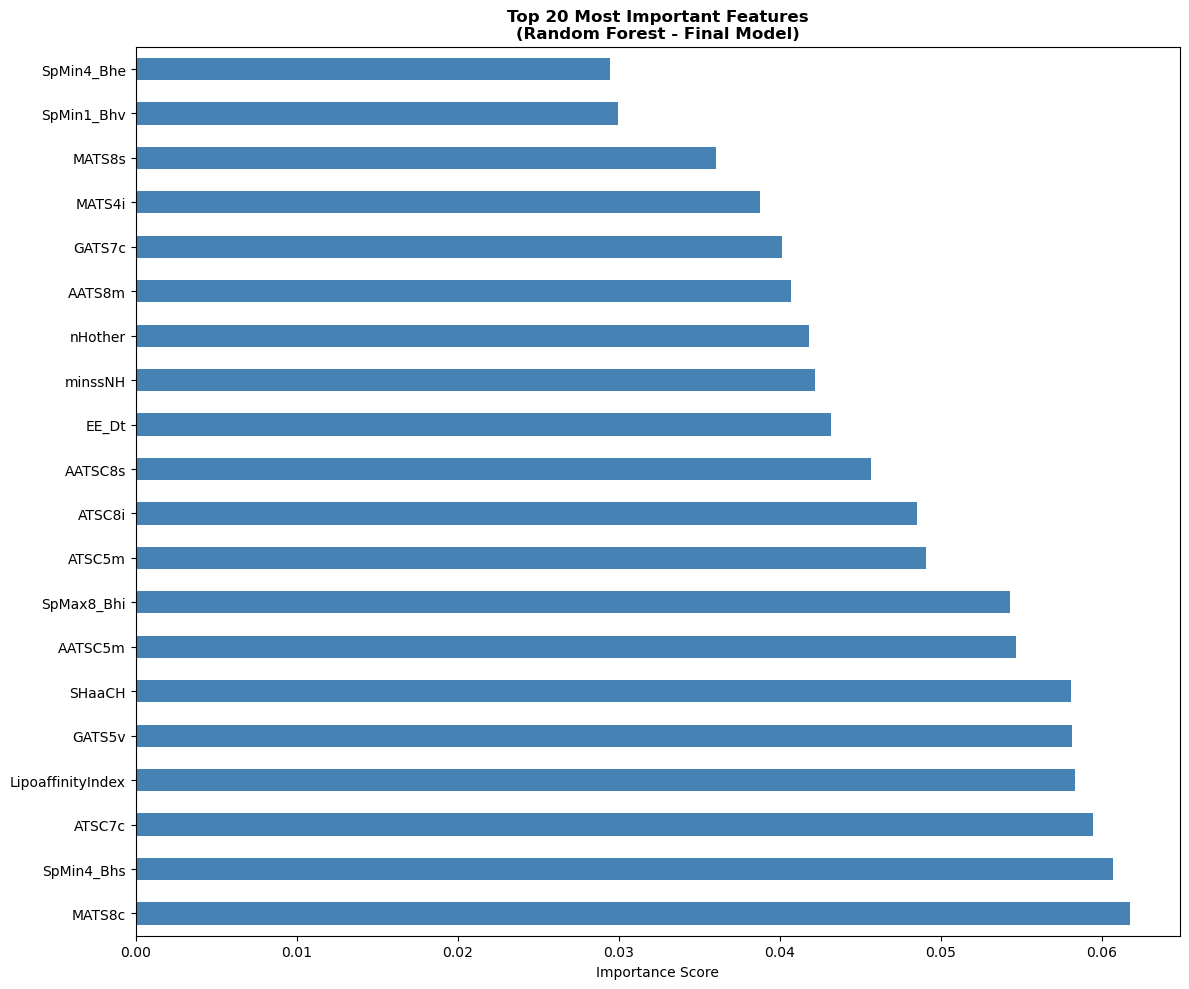

In [25]:
# Feature importance analysis for interpretability
print(f"\n{'='*60}")
print("FEATURE IMPORTANCE ANALYSIS")
print(f"{'='*60}")

# Get feature importance from Random Forest
rf_importance_final = pd.Series(best_rf.feature_importances_, index=final_feature_names)
rf_importance_sorted = rf_importance_final.sort_values(ascending=False)

print(f"\nTop 20 Most Important Features for Toxicity Prediction:")
for idx, (feat, imp) in enumerate(rf_importance_sorted.head(20).items(), 1):
    print(f"  {idx:2d}. {feat}: {imp:.4f}")

# Visualize top features
plt.figure(figsize=(12, 10))
rf_importance_sorted.head(20).plot(kind='barh', color='steelblue')
plt.title('Top 20 Most Important Features\n(Random Forest - Final Model)', 
          fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('final_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()